## Statistical Analysis Using R

In [ ]:
df <- read.csv("C:/Users/iqure/Downloads/airlines_flights_data.csv")
summary(df)

     index          airline             flight          source_city       
 Min.   :     0   Length:300153      Length:300153      Length:300153     
 1st Qu.: 75038   Class :character   Class :character   Class :character  
 Median :150076   Mode  :character   Mode  :character   Mode  :character  
 Mean   :150076                                                           
 3rd Qu.:225114                                                           
 Max.   :300152                                                           
 departure_time        stops           arrival_time       destination_city  
 Length:300153      Length:300153      Length:300153      Length:300153     
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
             

Now let's begin plotting the histograms for price and duration. 
First, let's load in the Cairo graphics package

In [2]:
library(Cairo)
options(device = Cairo)

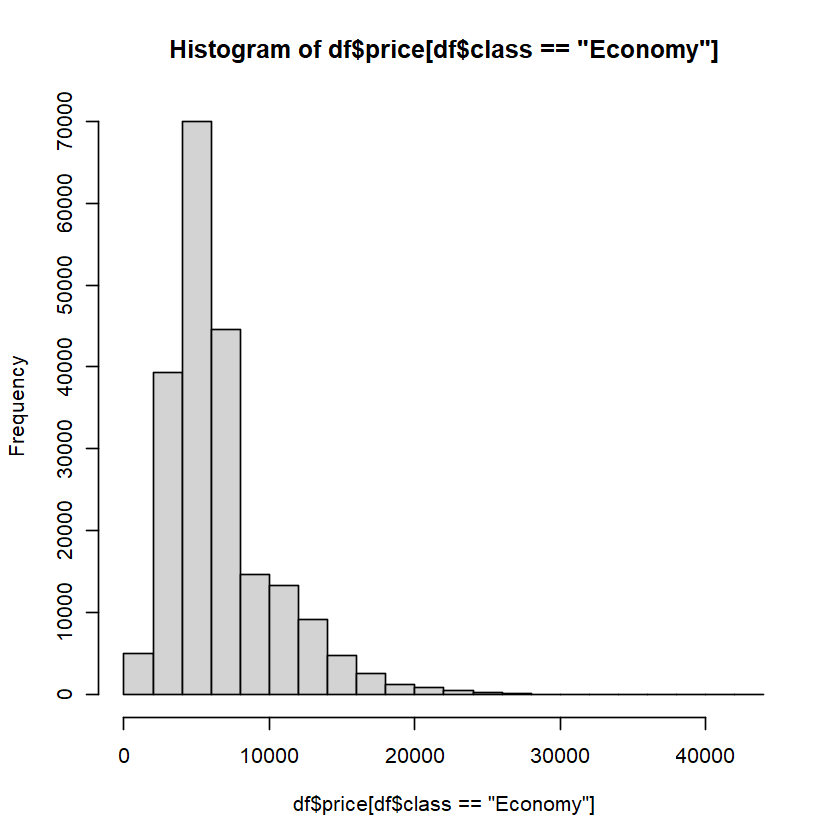

In [3]:
hist.price <- hist(df$price[df$class == "Economy"]) 

Heavily Right Skewed 

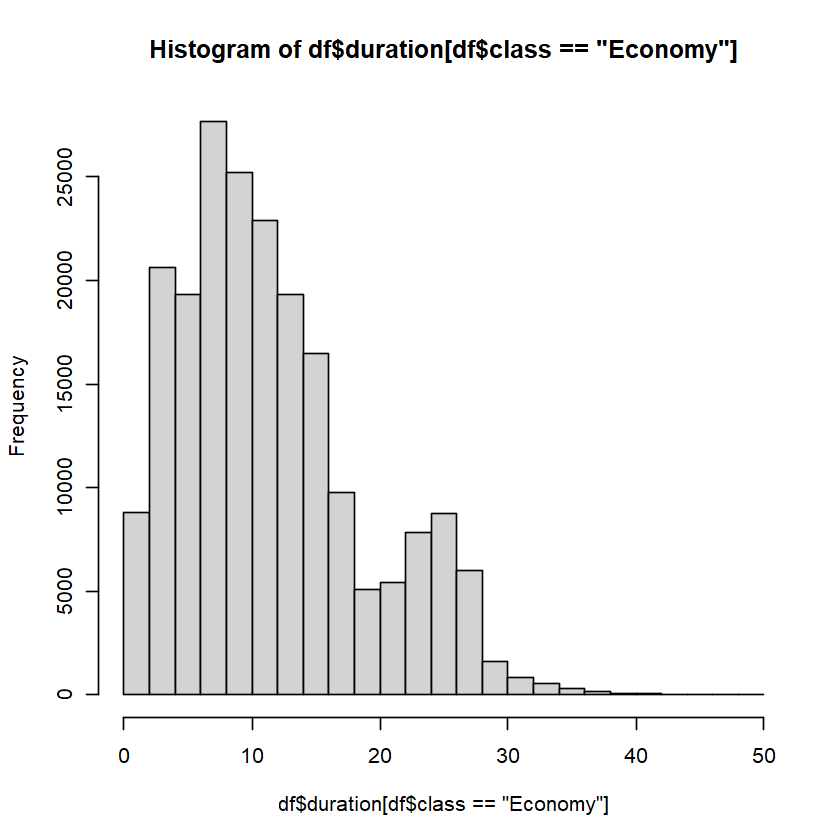

In [4]:
hist.duration <- hist(df$duration[df$class == "Economy"]) 

Mildly Right Skewed

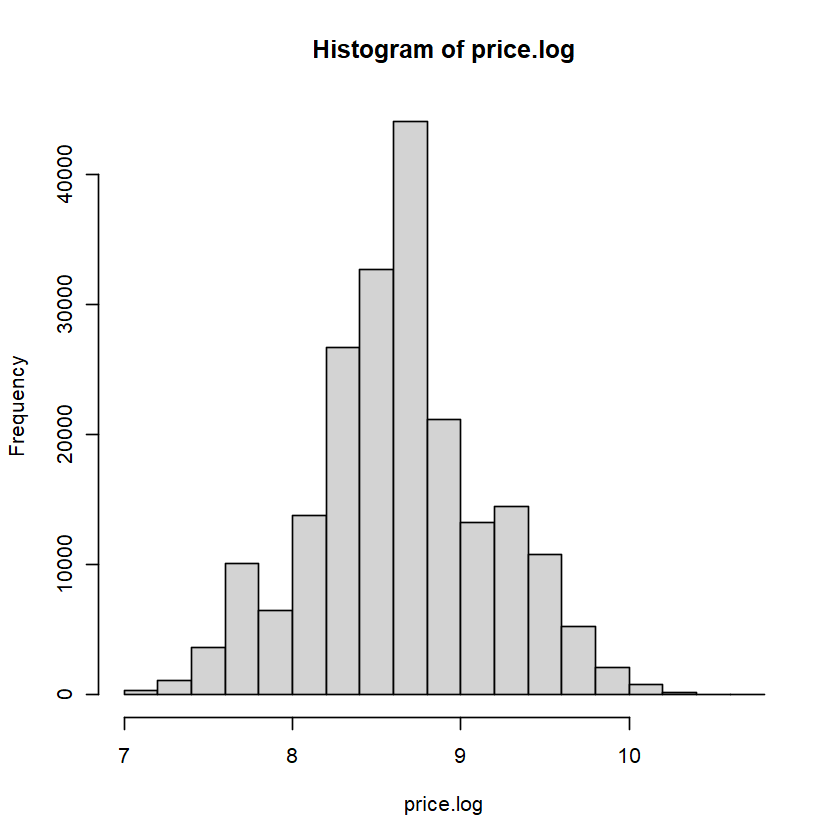

In [5]:
price.log <- log(df$price[df$class == "Economy"])
hist(price.log)

Logarithmic Price Transformation

Data is right-skewed so logarithmic method needed

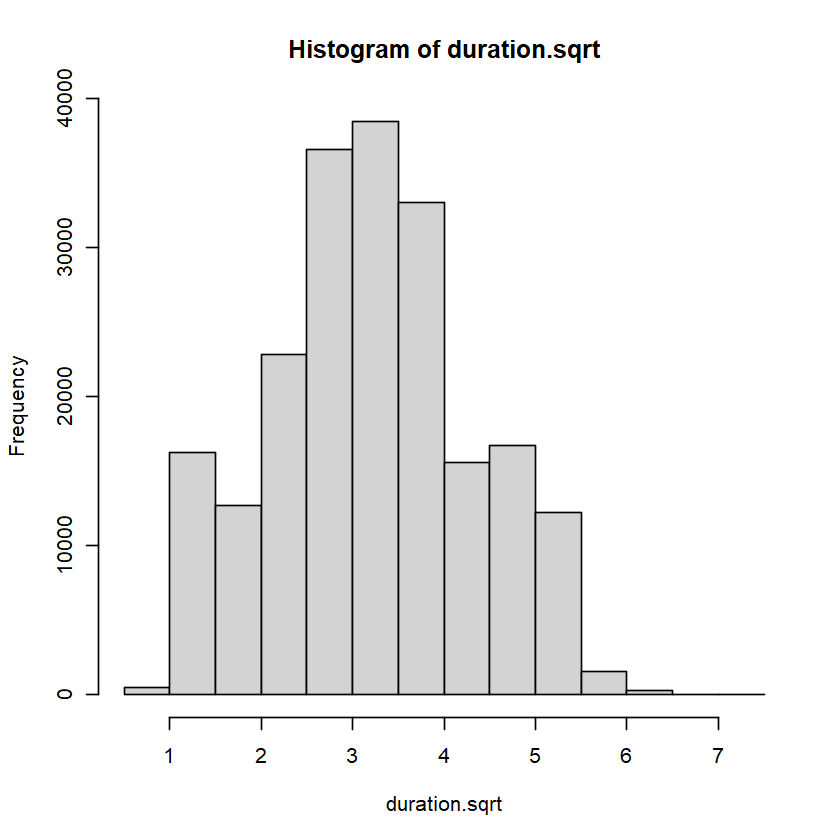

In [6]:
duration.sqrt <- sqrt(df$duration[df$class == "Economy"])
hist(duration.sqrt)

Square Root Duration Transformation 

Data is mildly right-skewed so square root method needed 

In [7]:
corr <- cor(price.log, duration.sqrt)
corr 

[1] 0.3868784

Correlation is .3868, a moderate positive correlation

Both variables have normal distributions, now let's plot a scatter plot 

Let's have duration predict price 

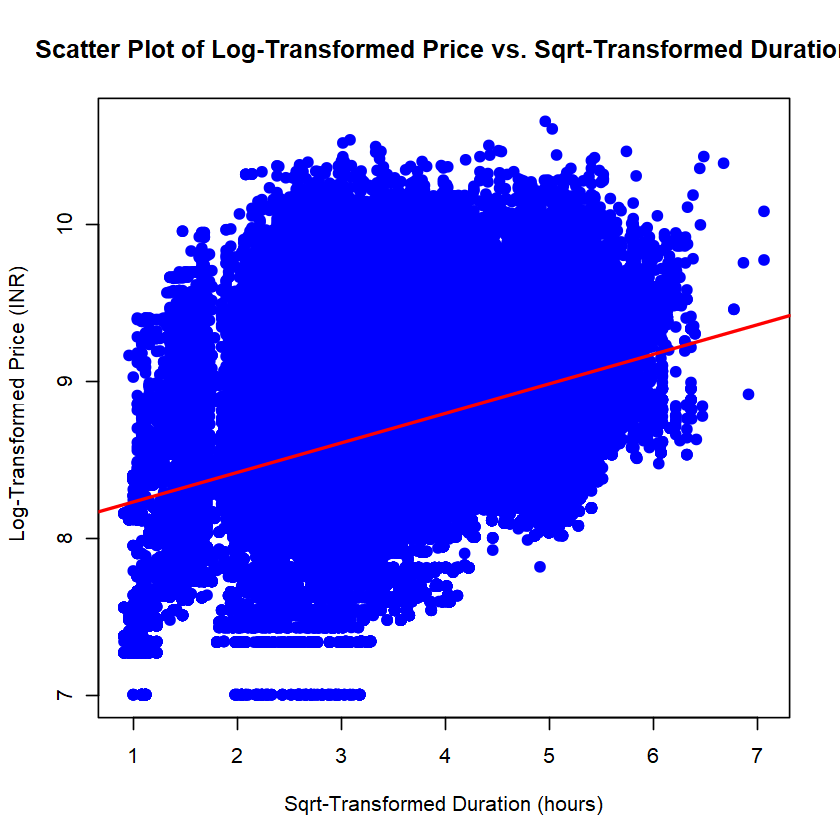

In [8]:
plot(price.log ~ duration.sqrt,
     main = "Scatter Plot of Log-Transformed Price vs. Sqrt-Transformed Duration",
     xlab = "Sqrt-Transformed Duration (hours)",
     ylab = "Log-Transformed Price (INR)",
     col = "blue", pch = 19)

abline(lm(price.log ~ duration.sqrt), col = "red", lwd = 2)

Let's get our scatter plot equation 

In [9]:
model <- lm(price.log ~ duration.sqrt)
summary(model) 


Call:
lm(formula = price.log ~ duration.sqrt)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.63439 -0.32450 -0.02836  0.30610  1.91141 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   8.0453178  0.0033488  2402.5   <2e-16 ***
duration.sqrt 0.1879349  0.0009854   190.7   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4863 on 206664 degrees of freedom
Multiple R-squared:  0.1497,	Adjusted R-squared:  0.1497 
F-statistic: 3.638e+04 on 1 and 206664 DF,  p-value: < 2.2e-16


### Equation is 8.0453 + .18789 * duration.sqrt ##

### When exponentiating .18789 to account for square root normalization, we get 1.2066, meaning for every 1 unit increase in sqrt duration, price increases by 20.66% ##

### When exponentiating 8.0453 to account for log normalization, we get 3123.45, the base price is 3,123.45 INR ##